# NHANES Cardiometabolic Exploration

Reads the star-schema marts in `exports/` (built by `scripts/build_dataset.py`) and charts the peer-group outlier detection: distributions, anomaly breakdowns, and where undiagnosed outliers cluster.

Run `python scripts/build_dataset.py` first if `exports/` is empty. This notebook only reads — it doesn't re-download or re-process anything.

In [1]:
import warnings

# same pandas 2.2.2 / Python 3.14 false-positive as build_dataset.py
warnings.filterwarnings("ignore", category=FutureWarning, message=".*ChainedAssignmentError.*")

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

EXPORT_DIR = Path("exports") if Path("exports").exists() else Path("../exports")

dim_respondents = pd.read_csv(EXPORT_DIR / "dim_respondents.csv")
fact_body = pd.read_csv(EXPORT_DIR / "fact_body_measures.csv")
fact_bp = pd.read_csv(EXPORT_DIR / "fact_blood_pressure.csv")
fact_labs = pd.read_csv(EXPORT_DIR / "fact_labs.csv")
fact_diagnoses = pd.read_csv(EXPORT_DIR / "fact_diagnoses.csv")
fact_anomalies = pd.read_csv(EXPORT_DIR / "fact_anomalies.csv")

# denormalized view for plotting — joins the star schema back together
wide = (
    dim_respondents
    .merge(fact_body, on="SEQN", how="left")
    .merge(fact_bp, on="SEQN", how="left")
    .merge(fact_labs, on="SEQN", how="left")
    .merge(fact_diagnoses, on="SEQN", how="left")
)

print(f"{len(wide):,} respondents, {len(fact_anomalies):,} flagged (respondent, field) pairs")

11,933 respondents, 757 flagged (respondent, field) pairs


## Distributions by age band

BMI, blood pressure, and fasting glucose across the sample, so the peer-group z-score thresholds have visual context.

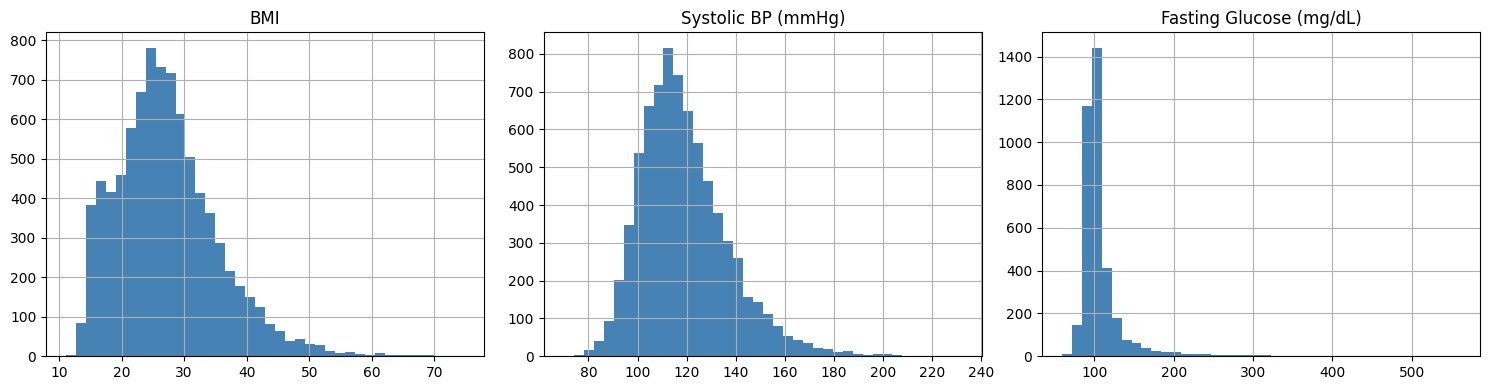

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ["bmi", "mean_systolic", "fasting_glucose"],
    ["BMI", "Systolic BP (mmHg)", "Fasting Glucose (mg/dL)"],
):
    wide[col].dropna().hist(bins=40, ax=ax, color="steelblue")
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Log scales for right-skewed biomarkers

Triglycerides, insulin, and fasting glucose are heavily right-skewed — a long tail of high values compresses the bulk of the distribution against the left axis on a linear scale. A **log(x) scale** spreads those out so the shape is readable and roughly symmetric, which is also why the peer-group z-scores and the glucose regression have such long-tailed residuals: the underlying quantities are closer to log-normal than normal. Top row is linear, bottom row is the same data on a log x-axis.

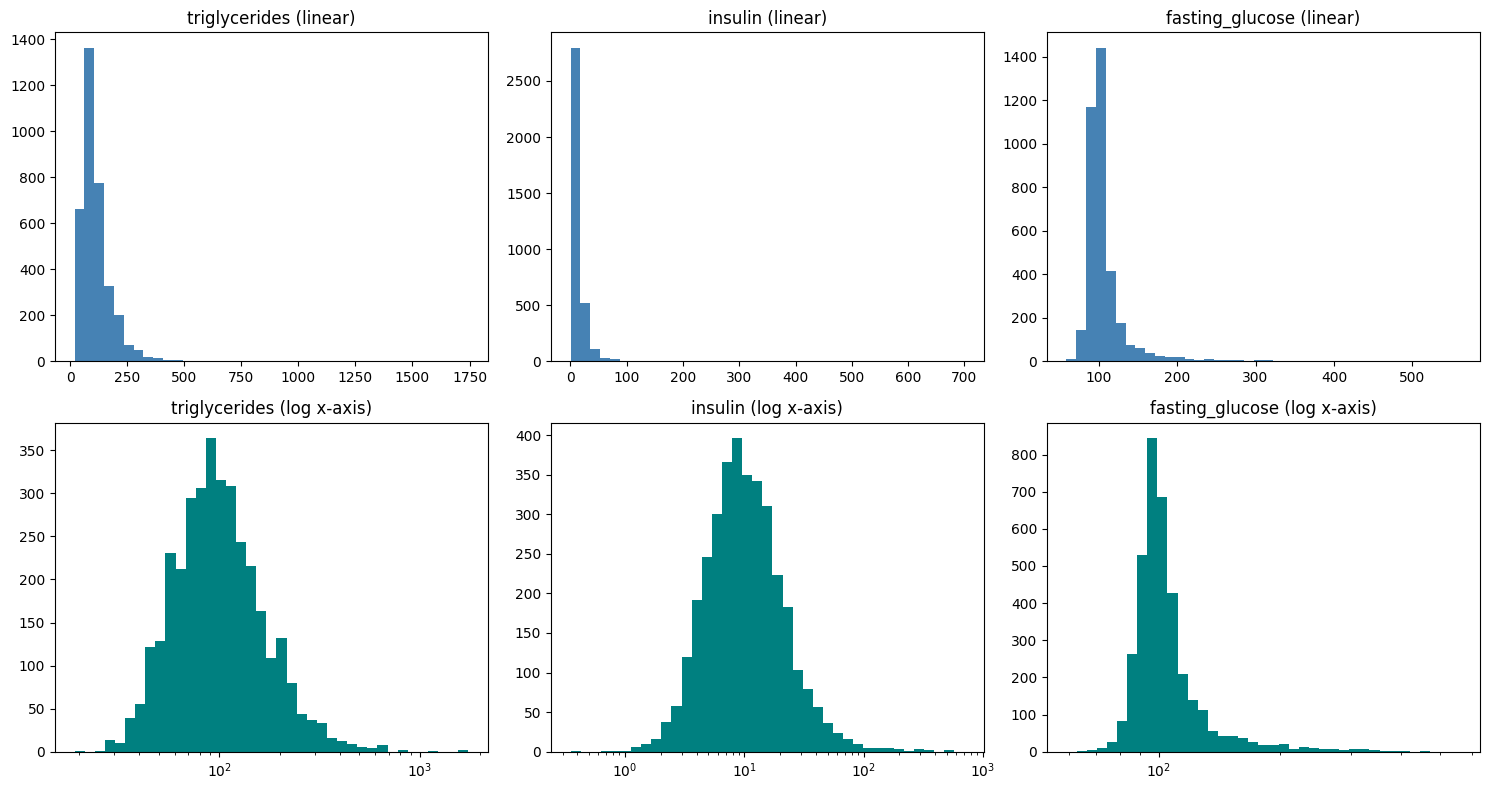

In [3]:
skewed = ["triglycerides", "insulin", "fasting_glucose"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, col in enumerate(skewed):
    data = wide[col].dropna()
    data = data[data > 0]  # log undefined at/below zero
    axes[0, j].hist(data, bins=40, color="steelblue")
    axes[0, j].set_title(f"{col} (linear)")
    # log-spaced bins so bars are even-width on the log axis
    log_bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 40)
    axes[1, j].hist(data, bins=log_bins, color="teal")
    axes[1, j].set_xscale("log")
    axes[1, j].set_title(f"{col} (log x-axis)")
plt.tight_layout()
plt.show()

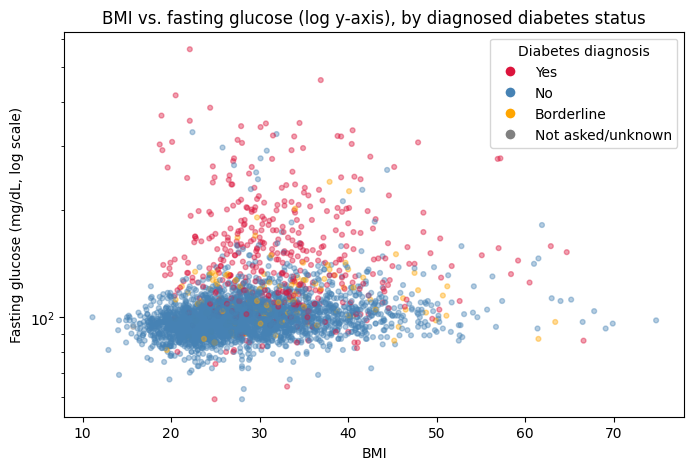

In [4]:
# the BMI-vs-glucose scatter from above, but with a log y-axis so the
# high-glucose tail (diabetic range) is legible instead of squashed
plot_df = wide.dropna(subset=["bmi", "fasting_glucose"])
plot_df = plot_df[plot_df["fasting_glucose"] > 0]
colors = plot_df["diabetes_diagnosis"].map(
    {"Yes": "crimson", "No": "steelblue", "Borderline": "orange"}
).fillna("gray")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["bmi"], plot_df["fasting_glucose"], c=colors, alpha=0.4, s=12)
ax.set_yscale("log")
ax.set_xlabel("BMI")
ax.set_ylabel("Fasting glucose (mg/dL, log scale)")
ax.set_title("BMI vs. fasting glucose (log y-axis), by diagnosed diabetes status")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=l)
           for l, c in [("Yes", "crimson"), ("No", "steelblue"), ("Borderline", "orange"), ("Not asked/unknown", "gray")]]
ax.legend(handles=handles, title="Diabetes diagnosis")
plt.show()

## Anomaly breakdown

Where the flagged (≥3 std dev from peer group) outliers concentrate — by field category and by age band.

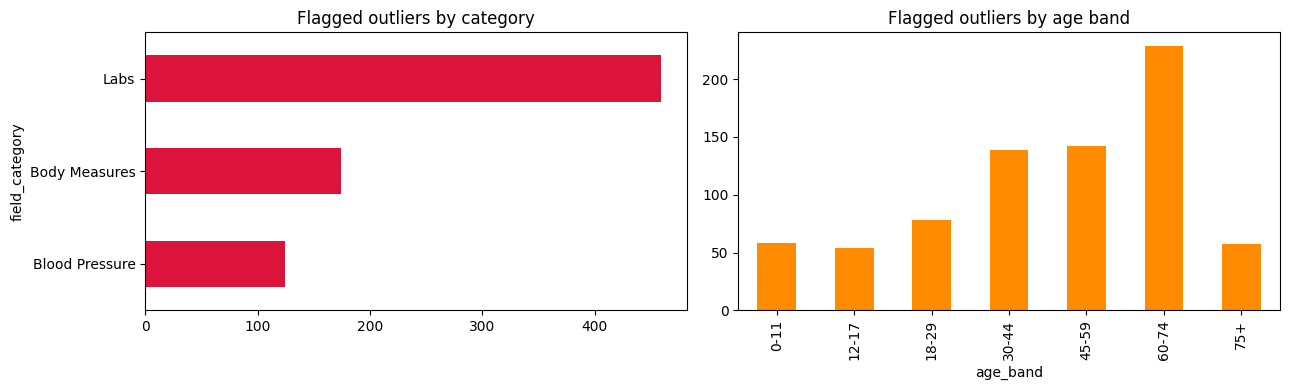

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fact_anomalies["field_category"].value_counts().plot(
    kind="barh", ax=axes[0], color="crimson", title="Flagged outliers by category"
)
axes[0].invert_yaxis()

anomalies_with_age = fact_anomalies.merge(dim_respondents[["SEQN", "age_band"]], on="SEQN")
anomalies_with_age["age_band"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="darkorange", title="Flagged outliers by age band"
)

plt.tight_layout()
plt.show()

## Undiagnosed outliers

BMI vs. fasting glucose, colored by self-reported diabetes diagnosis — outliers with no diagnosis on record are the interesting cluster.

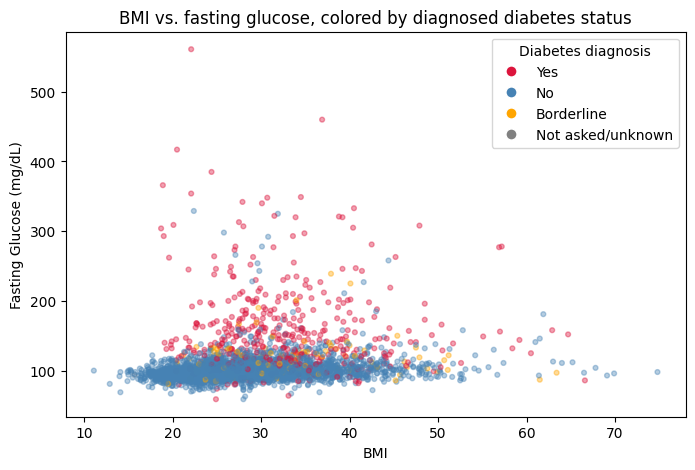

In [6]:
plot_df = wide.dropna(subset=["bmi", "fasting_glucose"])
colors = plot_df["diabetes_diagnosis"].map({"Yes": "crimson", "No": "steelblue", "Borderline": "orange"}).fillna("gray")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["bmi"], plot_df["fasting_glucose"], c=colors, alpha=0.4, s=12)
ax.set_xlabel("BMI")
ax.set_ylabel("Fasting Glucose (mg/dL)")
ax.set_title("BMI vs. fasting glucose, colored by diagnosed diabetes status")

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=l)
           for l, c in [("Yes", "crimson"), ("No", "steelblue"), ("Borderline", "orange"), ("Not asked/unknown", "gray")]]
ax.legend(handles=handles, title="Diabetes diagnosis")
plt.show()

## Summary table

In [7]:
summary = wide.groupby(["age_band", "gender"], observed=True).agg(
    respondents=("SEQN", "count"),
    avg_bmi=("bmi", "mean"),
    avg_systolic=("mean_systolic", "mean"),
    avg_glucose=("fasting_glucose", "mean"),
).round(1)
summary

respondents  avg_bmi  avg_systolic  avg_glucose
age_band gender                                                 
0-11     Female         1247     18.2         100.6          NaN
         Male           1298     18.3         101.8          NaN
12-17    Female          615     24.4         103.5         93.3
         Male            620     24.1         110.3         96.5
18-29    Female          672     28.1         106.8         93.7
         Male            576     27.0         117.3        102.1
30-44    Female         1006     30.7         111.0         99.5
         Male            754     29.2         120.1        104.5
45-59    Female          903     31.4         120.9        108.8
         Male            738     30.5         125.9        121.4
60-74    Female         1365     30.2         126.7        110.7
         Male           1148     29.3         128.9        118.2
75+      Female          550     28.9         136.9        110.1
         Male            441     28.3         129.5        116.5

## Regression: what predicts fasting glucose?

OLS regression of fasting glucose on BMI, waist circumference, systolic BP, and age. This is a second, independent way to spot outliers — the residual (actual minus predicted) flags respondents whose glucose is unusual given their other measurements, complementing the peer-group z-scores above.

In [8]:
import numpy as np
import statsmodels.api as sm

reg_df = wide.dropna(subset=["fasting_glucose", "bmi", "waist_cm", "mean_systolic", "age_years"]).copy()

X = sm.add_constant(reg_df[["bmi", "waist_cm", "mean_systolic", "age_years"]])
y = reg_df["fasting_glucose"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        fasting_glucose   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     87.25
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           1.05e-70
Time:                        20:21:05   Log-Likelihood:                -16670.
No. Observations:                3441   AIC:                         3.335e+04
Df Residuals:                    3436   BIC:                         3.338e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            42.4338      4.546      9.334

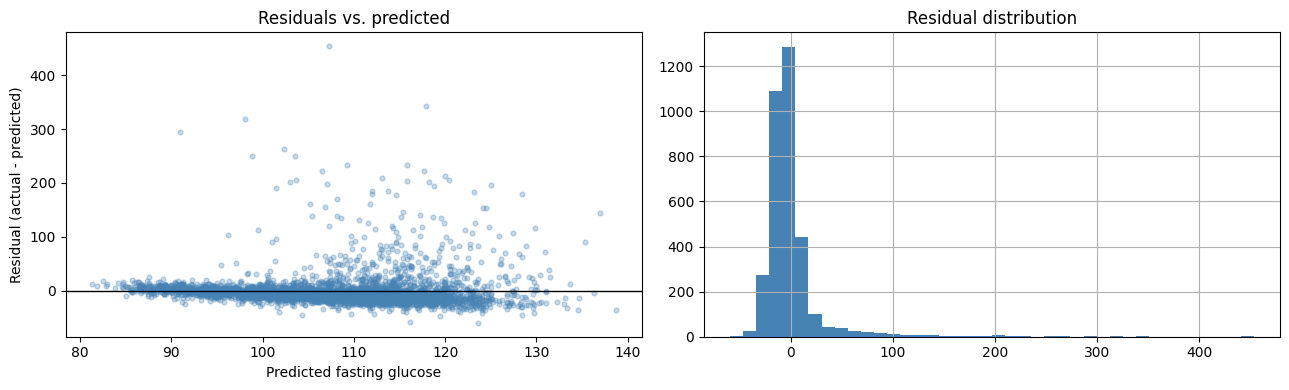

119 respondents (3.5%) have a glucose residual beyond 2 std devs of the model's prediction — glucose notably higher or lower than their BMI/BP/age alone would predict.


In [9]:
reg_df["predicted_glucose"] = model.predict(X)
reg_df["residual"] = reg_df["fasting_glucose"] - reg_df["predicted_glucose"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(reg_df["predicted_glucose"], reg_df["residual"], alpha=0.3, s=12, color="steelblue")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Predicted fasting glucose")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs. predicted")

reg_df["residual"].hist(bins=40, ax=axes[1], color="steelblue")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

large_residual = reg_df[reg_df["residual"].abs() >= 2 * reg_df["residual"].std()]
print(f"{len(large_residual):,} respondents ({len(large_residual) / len(reg_df):.1%}) have a glucose "
      f"residual beyond 2 std devs of the model's prediction \u2014 glucose notably higher or lower "
      f"than their BMI/BP/age alone would predict.")

## Clustering: cardiometabolic risk phenotypes

K-means on the fasting-subsample labs (only respondents with a full lab panel — cholesterol, glucose, HbA1c, insulin, plus BMI/waist/BP) to see if the data separates into distinct risk groups *without* using the diagnosis labels at all. Diabetes diagnosis rate per cluster, computed after the fact, is the sanity check that the clusters mean something clinically.

In [10]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cluster_fields = [
    "bmi", "waist_cm", "mean_systolic", "mean_diastolic",
    "total_cholesterol", "hdl_cholesterol", "triglycerides", "ldl_cholesterol",
    "fasting_glucose", "hba1c", "insulin",
]
cluster_df = wide.dropna(subset=cluster_fields).copy()

X_scaled = StandardScaler().fit_transform(cluster_df[cluster_fields])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

print(f"{len(cluster_df):,} respondents with a full lab panel, clustered into {kmeans.n_clusters} groups")
cluster_df["cluster"].value_counts().sort_index()

3,230 respondents with a full lab panel, clustered into 3 groups


cluster
0    1303
1     790
2    1137
Name: count, dtype: int64

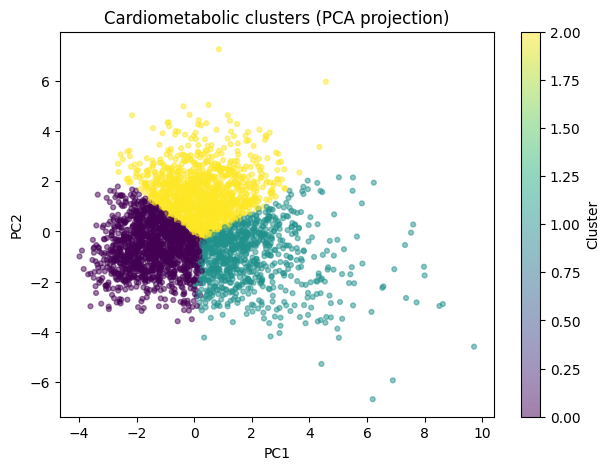

In [11]:
coords = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=cluster_df["cluster"], cmap="viridis", alpha=0.5, s=12)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Cardiometabolic clusters (PCA projection)")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [12]:
profile = cluster_df.groupby("cluster")[cluster_fields].mean().round(1)
profile["respondents"] = cluster_df.groupby("cluster").size()
profile["diabetes_rate"] = cluster_df.groupby("cluster")["diabetes_diagnosis"].apply(
    lambda s: (s == "Yes").mean()
).round(2)
profile

,bmi,waist_cm,mean_systolic,mean_diastolic,total_cholesterol,hdl_cholesterol,triglycerides,ldl_cholesterol,fasting_glucose,hba1c,insulin,respondents,diabetes_rate
cluster,,,,,,,,,,,,,
0,24.6,86.5,111.6,66.5,160.5,56.2,80.6,88.2,97.2,5.3,9.7,1303,0.04
1,35.8,116.7,124.8,76.3,164.9,46.1,146.0,89.6,130.8,6.5,28.1,790,0.35
2,29.0,99.5,125.8,78.1,222.0,59.2,121.0,138.6,101.4,5.5,10.3,1137,0.04


## Lean Six Sigma: process capability against clinical reference ranges

Treating each lab/vital as a "process" and its established clinical normal range as spec limits (LSL/USL), the standard Six Sigma capability metrics apply directly: **Cp** (potential capability, ignores centering), **Cpk** (actual capability, accounts for how centered the population is within spec), **% out of spec**, **DPMO**, and the equivalent **sigma level** (long-term convention with the standard 1.5-sigma shift). A lower Cpk/sigma level means more of the sampled population falls outside the healthy range — either real prevalence of a condition or population variability, not a measurement defect, but the same math applies.

In [13]:
from scipy.stats import norm

# (LSL, USL, unit) per metric \u2014 established clinical reference ranges.
# LSL is None where no clinically meaningful lower bound is commonly used.
SPEC_LIMITS = {
    "bmi":              (18.5, 25.0, "kg/m^2"),
    "mean_systolic":    (90.0, 120.0, "mmHg"),
    "fasting_glucose":  (70.0, 99.0, "mg/dL"),
    "hba1c":            (None, 5.7, "%"),
    "total_cholesterol": (None, 200.0, "mg/dL"),
    "ldl_cholesterol":  (None, 100.0, "mg/dL"),
}


def capability(series, lsl, usl):
    s = series.dropna()
    mean, std = s.mean(), s.std()
    cp = (usl - lsl) / (6 * std) if lsl is not None else np.nan
    cpu = (usl - mean) / (3 * std)
    cpl = (mean - lsl) / (3 * std) if lsl is not None else np.inf
    cpk = min(cpu, cpl)
    frac_out = ((s < (lsl if lsl is not None else -np.inf)) | (s > usl)).mean()
    dpmo = frac_out * 1_000_000
    sigma_level = norm.isf(frac_out) + 1.5 if 0 < frac_out < 1 else np.nan
    return pd.Series({
        "n": len(s), "mean": round(mean, 1), "std": round(std, 2),
        "Cp": round(cp, 2) if not np.isnan(cp) else None,
        "Cpk": round(cpk, 2),
        "pct_out_of_spec": round(frac_out * 100, 1),
        "DPMO": round(dpmo),
        "sigma_level": round(sigma_level, 2) if not np.isnan(sigma_level) else None,
    })


rows = {}
for field, (lsl, usl, unit) in SPEC_LIMITS.items():
    rows[f"{field} ({unit})"] = capability(wide[field], lsl, usl)

capability_table = pd.DataFrame(rows).T
capability_table

,n,mean,std,Cp,Cpk,pct_out_of_spec,DPMO,sigma_level
bmi (kg/m^2),8471.0,27.2,8.14,0.13,-0.09,71.4,714201.0,0.93
mean_systolic (mmHg),7518.0,119.1,18.15,0.28,0.02,43.4,434025.0,1.67
fasting_glucose (mg/dL),3672.0,107.9,32.48,0.15,-0.09,52.1,521242.0,1.45
hba1c (%),6715.0,5.7,1.05,NaN,-0.00,28.9,289054.0,2.06
total_cholesterol (mg/dL),6890.0,181.5,42.32,NaN,0.15,29.5,294775.0,2.04
ldl_cholesterol (mg/dL),3480.0,105.7,36.29,NaN,-0.05,52.2,521839.0,1.45


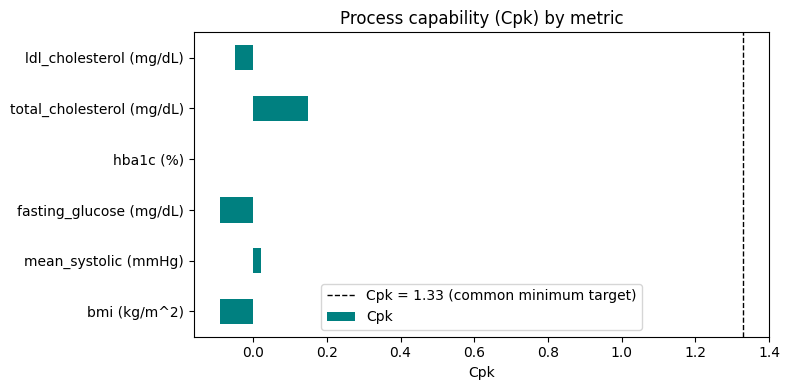

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
capability_table["Cpk"].astype(float).plot(kind="barh", ax=ax, color="teal")
ax.axvline(1.33, color="black", linestyle="--", linewidth=1, label="Cpk = 1.33 (common minimum target)")
ax.set_xlabel("Cpk")
ax.set_title("Process capability (Cpk) by metric")
ax.legend()
plt.tight_layout()
plt.show()

## Regression target 2: blood pressure by diagnosed condition

Same idea as the glucose regression above, but now the diagnosed conditions (diabetes, high cholesterol, smoking status) go in as categorical **factors** alongside BMI/waist/age, rather than as a target — this quantifies how much each condition shifts systolic BP *after* controlling for body measures and age, i.e. comparing condition groups on equal footing rather than raw group averages.

In [15]:
import statsmodels.formula.api as smf

cond_df = wide.dropna(subset=[
    "mean_systolic", "bmi", "waist_cm", "age_years",
    "diabetes_diagnosis", "high_cholesterol_diagnosis", "smoking_status",
]).copy()
# drop the small Borderline diabetes group so the factor is a clean Yes/No comparison
cond_df = cond_df[cond_df["diabetes_diagnosis"] != "Borderline"]

condition_model = smf.ols(
    "mean_systolic ~ bmi + waist_cm + age_years "
    "+ C(diabetes_diagnosis, Treatment(reference='No')) "
    "+ C(high_cholesterol_diagnosis, Treatment(reference='No')) "
    "+ C(smoking_status, Treatment(reference='Never smoker'))",
    data=cond_df,
).fit()
print(condition_model.summary())

                            OLS Regression Results                            
Dep. Variable:          mean_systolic   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     162.5
Date:                Wed, 08 Jul 2026   Prob (F-statistic):          1.27e-219
Time:                        20:21:06   Log-Likelihood:                -23798.
No. Observations:                5659   AIC:                         4.761e+04
Df Residuals:                    5651   BIC:                         4.767e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

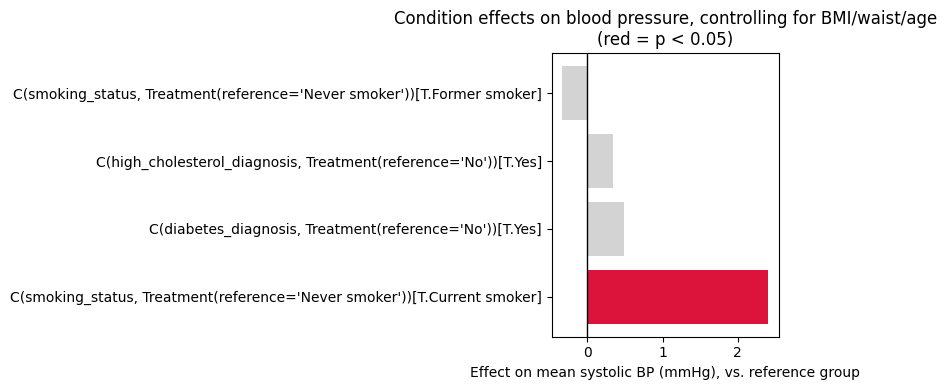

,systolic_mmHg_effect,p_value
"C(smoking_status, Treatment(reference='Never smoker'))[T.Current smoker]",2.41,0.0002
"C(diabetes_diagnosis, Treatment(reference='No'))[T.Yes]",0.48,0.4727
"C(high_cholesterol_diagnosis, Treatment(reference='No'))[T.Yes]",0.34,0.5029
"C(smoking_status, Treatment(reference='Never smoker'))[T.Former smoker]",-0.34,0.5245


In [16]:
# isolate just the condition-factor coefficients (the C(...) terms)
condition_terms = [t for t in condition_model.params.index if t.startswith("C(")]
condition_effects = pd.DataFrame({
    "systolic_mmHg_effect": condition_model.params[condition_terms].round(2),
    "p_value": condition_model.pvalues[condition_terms].round(4),
}).sort_values("systolic_mmHg_effect", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["crimson" if p < 0.05 else "lightgray" for p in condition_effects["p_value"]]
ax.barh(condition_effects.index, condition_effects["systolic_mmHg_effect"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Effect on mean systolic BP (mmHg), vs. reference group")
ax.set_title("Condition effects on blood pressure, controlling for BMI/waist/age\n(red = p < 0.05)")
plt.tight_layout()
plt.show()
condition_effects

## Regression target 3: predicting diabetes diagnosis from biomarkers

Flips the setup around — diagnosis is now the **target** (logistic regression, Yes/No) instead of a factor, predicted from BMI, waist, systolic BP, age, total cholesterol, and fasting glucose. Coefficients are reported as odds ratios: an odds ratio of 1.5 for a predictor means each one-unit increase multiplies the odds of a diabetes diagnosis by 1.5x, holding the others constant.

In [17]:
logit_fields = ["bmi", "waist_cm", "mean_systolic", "age_years", "total_cholesterol", "fasting_glucose"]

logit_df = wide[wide["diabetes_diagnosis"].isin(["Yes", "No"])].dropna(subset=logit_fields).copy()
logit_df["diabetes_binary"] = (logit_df["diabetes_diagnosis"] == "Yes").astype(int)

X_logit = sm.add_constant(logit_df[logit_fields])
y_logit = logit_df["diabetes_binary"]
logit_model = sm.Logit(y_logit, X_logit).fit()
print(logit_model.summary())

odds_ratios = np.exp(logit_model.params).rename("odds_ratio").round(3)
print("\nOdds ratios:")
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.208417
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        diabetes_binary   No. Observations:                 3192
Model:                          Logit   Df Residuals:                     3185
Method:                           MLE   Df Model:                            6
Date:                Wed, 08 Jul 2026   Pseudo R-squ.:                  0.4367
Time:                        20:21:06   Log-Likelihood:                -665.27
converged:                       True   LL-Null:                       -1181.1
Covariance Type:            nonrobust   LLR p-value:                1.302e-219
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -9.4826      0.824    -11.512      0.000     -11.097      -7.868
bmi     

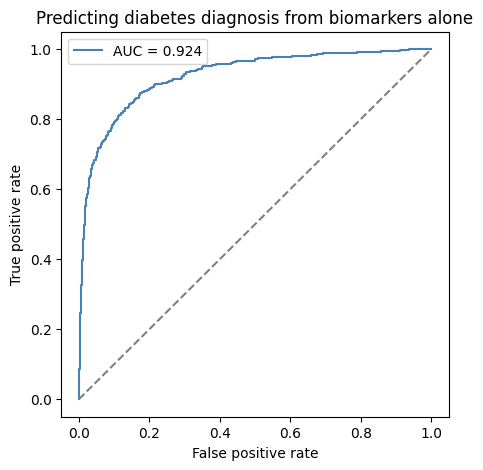

388 of 3,192 respondents (12.2%) have a diabetes diagnosis in this fully-observed biomarker subset.


In [18]:
from sklearn.metrics import roc_auc_score, roc_curve

predicted_prob = logit_model.predict(X_logit)
auc = roc_auc_score(y_logit, predicted_prob)
fpr, tpr, _ = roc_curve(y_logit, predicted_prob)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Predicting diabetes diagnosis from biomarkers alone")
ax.legend()
plt.show()

print(f"{y_logit.sum():,} of {len(y_logit):,} respondents ({y_logit.mean():.1%}) have a diabetes "
      f"diagnosis in this fully-observed biomarker subset.")

## Regression target 4: condition burden across all three diagnosis types

Combines diabetes, hypertension, and high-cholesterol diagnosis into a single **condition burden** category (0, 1, 2, or all 3 diagnosed) and predicts it with a multinomial logistic regression from the same biomarker set as the diabetes model above. Unlike the binary diabetes model, this uses all three diagnosis types together as one multi-level target, so "0 conditions" is the reference category every other category is compared against.

In [19]:
condition_fields = ["diabetes_diagnosis", "high_bp_diagnosis", "high_cholesterol_diagnosis"]

mn_df = wide.dropna(subset=condition_fields + logit_fields).copy()
mn_df = mn_df[mn_df["diabetes_diagnosis"] != "Borderline"]

# keep this numeric (not a string) -- mnlogit's formula endog needs plain
# integer category codes; a string/object column gets dummy-encoded by
# Patsy into a multi-column indicator matrix instead, which mnlogit rejects.
mn_df["condition_burden"] = (
    (mn_df["diabetes_diagnosis"] == "Yes").astype(int)
    + (mn_df["high_bp_diagnosis"] == "Yes").astype(int)
    + (mn_df["high_cholesterol_diagnosis"] == "Yes").astype(int)
)

print("Respondents per condition-burden category:")
print(mn_df["condition_burden"].value_counts().sort_index())

Respondents per condition-burden category:
condition_burden
0    1369
1     830
2     568
3     208
Name: count, dtype: int64


In [20]:
mnlogit_model = smf.mnlogit(
    "condition_burden ~ bmi + waist_cm + mean_systolic + age_years "
    "+ total_cholesterol + fasting_glucose",
    data=mn_df,
).fit()
print(mnlogit_model.summary())
print(f"\nPseudo R-squared: {mnlogit_model.prsquared:.3f}")

Optimization terminated successfully.
         Current function value: 0.961734
         Iterations 8


                          MNLogit Regression Results                          
Dep. Variable:       condition_burden   No. Observations:                 2975
Model:                        MNLogit   Df Residuals:                     2954
Method:                           MLE   Df Model:                           18
Date:                Wed, 08 Jul 2026   Pseudo R-squ.:                  0.2088
Time:                        20:21:07   Log-Likelihood:                -2861.2
converged:                       True   LL-Null:                       -3616.0
Covariance Type:            nonrobust   LLR p-value:                3.820e-310
condition_burden=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -7.4602      0.553    -13.500      0.000      -8.543      -6.377
bmi                    0.0135      0.017      0.789      0.430      -0.020       0.047
waist_cm            

In [21]:
categories = sorted(mn_df["condition_burden"].unique())
non_reference = [c for c in categories if c != 0]

# relative risk ratios: exp(coef) vs the 0-conditions reference category
rrr = np.exp(mnlogit_model.params)
rrr.columns = [f"{c} condition(s) vs. 0" for c in non_reference]
rrr.round(3)

,1 condition(s) vs. 0,2 condition(s) vs. 0,3 condition(s) vs. 0
Intercept,0.001,0.000,0.000
bmi,1.014,1.038,1.006
waist_cm,1.006,1.014,1.045
mean_systolic,1.015,1.023,1.018
age_years,1.047,1.078,1.089
total_cholesterol,1.004,0.996,0.989
fasting_glucose,1.011,1.023,1.035


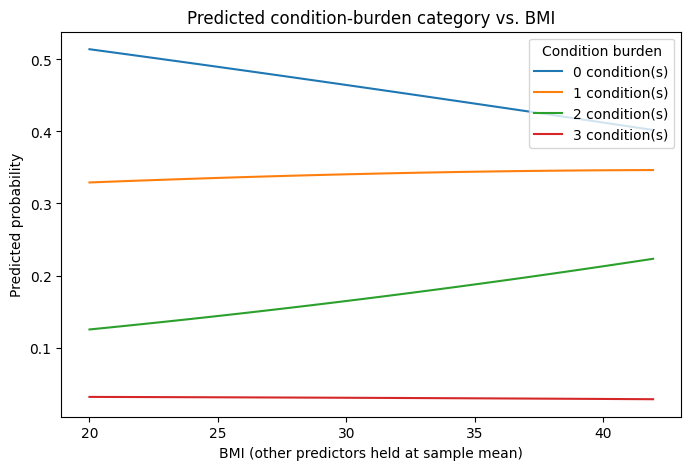

In [22]:
# predicted probability of each condition-burden category across the BMI range,
# holding every other predictor at its sample mean
grid = pd.DataFrame({"bmi": np.linspace(mn_df["bmi"].quantile(0.05), mn_df["bmi"].quantile(0.95), 50)})
for col in ["waist_cm", "mean_systolic", "age_years", "total_cholesterol", "fasting_glucose"]:
    grid[col] = mn_df[col].mean()

pred_probs = mnlogit_model.predict(grid)
pred_probs.columns = [f"{c} condition(s)" for c in categories]

fig, ax = plt.subplots(figsize=(8, 5))
for col in pred_probs.columns:
    ax.plot(grid["bmi"], pred_probs[col], label=col)
ax.set_xlabel("BMI (other predictors held at sample mean)")
ax.set_ylabel("Predicted probability")
ax.set_title("Predicted condition-burden category vs. BMI")
ax.legend(title="Condition burden")
plt.show()